## Mandatory EDA for CIFAR-10 DataSet

In [3]:
import torch
from torch import nn
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("talk") # Makes the plots more readable


We download the data into the ./data subfolder. Notice we are not applying complex augmentations yet. For EDA, we want to see the raw data as much as possible.

In [4]:
# Note: We are only loading it here for EDA. The formal data pipeline
# will be defined in dataset.py. We are not applying any transforms yet
# besides ToTensor to facilitate analysis.

train_dataset  =  torchvision.datasets.CIFAR10(root='./data',
                                               train=True,
                                               download=True) 
test_dataset   =  torchvision.datasets.CIFAR10(root='./data',
                                               train=False,
                                               download=True)
#class names
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

**Basic Dataset Inspection :**
This cell gives us the vital statistics: 50,000 training images, 10,000 test images. The .data attribute reveals the underlying NumPy array shape: (50000, 32, 32, 3), which is crucial for understanding the input dimensions of our future model.

In [6]:
print(f"Number of training samples : {len(train_dataset)}")
print(f"Number of testing  samples : {len(test_dataset)}")

img, label = train_dataset[0]
print(f"Type of a single image: {type(img)}")
print(f"Label of the First image : {(label)} ({classes[label]})")

print(f"Shape of the training data tensor: {train_dataset.data.shape}")
print(f"Shape of the training targets tensor: {len(train_dataset.targets)}")

Number of training samples : 50000
Number of testing  samples : 10000
Type of a single image: <class 'PIL.Image.Image'>
Label of the First image : 6 (frog)
Shape of the training data tensor: (50000, 32, 32, 3)
Shape of the training targets tensor: 50000


**Analyze Class Distribution :**
This is arguably the most important step in a classification EDA. We have just proven that the CIFAR-10 dataset is perfectly balanced. Each class has exactly 5,000 training images. This is a key insight: it means 'accuracy' is a valid and easy-to-interpret metric for model performance during training, although we will still use a full classification report for our final analysis.


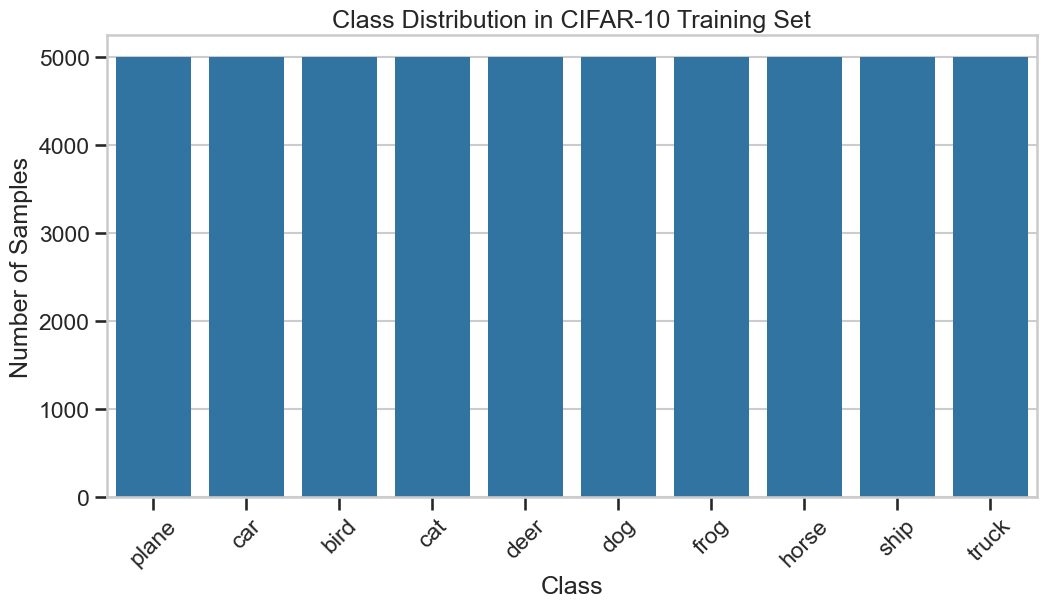

Class counts:
- plane: 5000 samples
- car: 5000 samples
- bird: 5000 samples
- cat: 5000 samples
- deer: 5000 samples
- dog: 5000 samples
- frog: 5000 samples
- horse: 5000 samples
- ship: 5000 samples
- truck: 5000 samples


In [7]:
train_labels = train_dataset.targets
train_counts = Counter(train_labels)
train_counts = sorted(train_counts.items())
class_indices, counts = zip(*train_counts)
class_names = [classes[i] for i in class_indices]
plt.figure(figsize=(12, 6))
sns.barplot(x=class_names, y=list(counts))
plt.title('Class Distribution in CIFAR-10 Training Set')
plt.xlabel('Class')
plt.ylabel('Number of Samples')
plt.xticks(rotation=45)
plt.show()
print("Class counts:")
for name, count in zip(class_names, counts):
    print(f"- {name}: {count} samples")

**Analyze Pixel Value Distribution :**
This analysis confirms that the pixel values range from 0 to 255. The distribution is somewhat centered but not perfectly Gaussian. This confirms our standard practice for image data:

1. **Scale:** Convert images to Tensors, which scales values from to [0.0, 1.0].
2. **Normalize:** Standardize the pixel values (subtract mean, divide by standard deviation). This helps the model converge faster by centering the data distribution around zero. We will calculate the exact mean and std for the entire dataset in our `dataset.py` file.


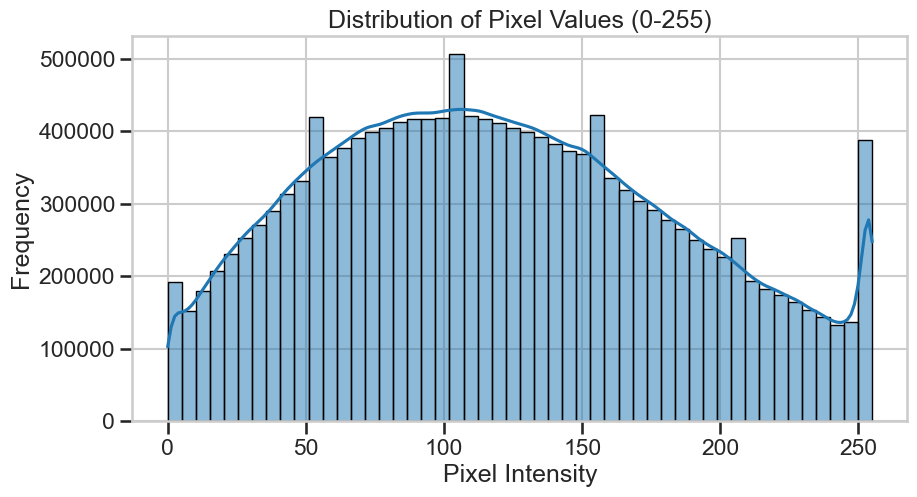

Pixel value min: 0
Pixel value max: 255
Pixel value mean: 120.46
Pixel value std: 64.40


In [8]:
# Convert to a NumPy array for easier manipulation
# We'll take a subset to speed up the process
subset_data = train_dataset.data[:5000]

# Flatten the image data to a 1D array of pixel values
pixel_values = subset_data.flatten()

plt.figure(figsize=(10, 5))
sns.histplot(pixel_values, bins=50, kde=True)
plt.title('Distribution of Pixel Values (0-255)')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')
plt.show()

print(f"Pixel value min: {pixel_values.min()}")
print(f"Pixel value max: {pixel_values.max()}")
print(f"Pixel value mean: {pixel_values.mean():.2f}")
print(f"Pixel value std: {pixel_values.std():.2f}")

### Key Takeaways

1.  **Dataset Size:** 50,000 training images and 10,000 testing images. This is a reasonably sized dataset, large enough to train a deep model but small enough to iterate quickly.

2.  **Image Dimensions:** All images are 32x32 pixels with 3 color channels (RGB). Our model's input layer must be designed to accept this shape.

3.  **Class Balance:** The dataset is **perfectly balanced**, with 5,000 images per class. This simplifies model evaluation, making accuracy a meaningful metric.

4.  **Data Type:** The raw data consists of uint8 pixel values ranging from 0 to 255.

### Actionable Insights for Modeling

*   **Input Layer:** Our CNN must accept a `(batch_size, 3, 32, 32)` tensor.
*   **Preprocessing:** A mandatory preprocessing pipeline in `dataset.py` will need to:
    *   Convert PIL Images to PyTorch Tensors (scaling values to [0, 1]).
    *   Normalize the tensors using the dataset's mean and standard deviation.
*   **Evaluation:** Since the classes are balanced, we can confidently monitor `accuracy` during training as our primary indicator of progress. However, for the final analysis, a full confusion matrix and classification report will provide a more complete picture.
*   **Data Augmentation:** The images are simple, but the intra-class variation is high. Data augmentation (random flips, rotations, crops) will be essential for building a robust model and preventing overfitting.